# Strategy Comparison

Loads all runs from `results/portfolio/` and `results/trades/`, auto-parses parameters from filenames, and produces a side-by-side comparison across strategies.

In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl

PORTFOLIO_DIR = Path("../results/portfolio")
TRADES_DIR    = Path("../results/trades")

# ── filename parser ────────────────────────────────────────────────────────
_PARAM_RE = re.compile(
    r"_tf(?P<tf>[^_]+)"
    r"_zw(?P<zw>[^_]+)"
    r"_wd(?P<wd>[^_]+)"
    r"_ze(?P<ze>[^_]+)"
    r"_zx(?P<zx>[^_]+)"
    r"_zs(?P<zs>[^_]+)"
    r"(?:_lhl(?P<lhl>[^_]+))?"
    r"(?:_hhl(?P<hhl>[^_]+))?"
    r"_mp(?P<mp>[^_]+)"
    r"_mh(?P<mh>[^_]+)"
    r"_mbr(?P<mbr>[^_]+)"
    r"_cb(?P<cb>[^_]+)"
    r"(?:_pv(?P<pv>[^_]+))?"
    r"_(?P<start>\d{4}-\d{2}-\d{2})"
    r"_(?P<end>\d{4}-\d{2}-\d{2})"
)

def _parse_params(stem: str) -> dict:
    m = _PARAM_RE.search(stem)
    if not m:
        return {}
    d = m.groupdict()
    return {
        "tf":    d["tf"],
        "zw":    float(d["zw"]),
        "wd":    int(d["wd"]),
        "ze":    float(d["ze"]),
        "zx":    float(d["zx"]),
        "zs":    float(d["zs"]),
        "lhl":   int(d["lhl"]) if d.get("lhl") else None,
        "hhl":   int(d["hhl"]) if d.get("hhl") else None,
        "mp":    int(d["mp"]),
        "mh":    int(d["mh"]),
        "mbr":   int(d["mbr"]),
        "cb":    float(d["cb"]),
        "pv":    d.get("pv"),  # None for files without this param
        "start": d["start"],
        "end":   d["end"],
    }

# ── load portfolio files ───────────────────────────────────────────────────
portfolio_files = sorted(PORTFOLIO_DIR.glob("daily_pnl_*.parquet"))
print(f"Found {len(portfolio_files)} portfolio file(s)")

runs: list[dict] = []
for pf in portfolio_files:
    params = _parse_params(pf.stem)
    if not params:
        print(f"  WARNING: could not parse params from {pf.name!r} — skipping")
        continue

    pnl = (
        pl.read_parquet(pf)
        .with_columns(pl.col("date").cast(pl.Date))
        .sort("date")
        .to_pandas()
        .set_index("date")
    )

    # match trades file by the same suffix after the prefix
    suffix = pf.stem.replace("daily_pnl", "", 1)
    tf = TRADES_DIR / f"trades{suffix}.parquet"
    trades = pl.read_parquet(tf).to_pandas() if tf.exists() else pd.DataFrame()

    runs.append({"params": params, "pnl": pnl, "trades": trades, "file": pf.name})

print(f"Loaded {len(runs)} run(s) successfully")

In [ ]:
# ── build short labels that only show differing parameters ─────────────────
PARAM_DISPLAY = {
    "tf": "tf", "zw": "zw", "wd": "wd", "ze": "ze", "zx": "zx",
    "zs": "zs", "lhl": "lhl", "hhl": "hhl", "mp": "mp",
    "mh": "mh", "mbr": "mbr", "cb": "cb", "pv": "pv",
}

def _build_labels(runs: list[dict]) -> list[str]:
    if len(runs) == 1:
        return [_full_label(runs[0]["params"])]
    all_params = [r["params"] for r in runs]
    keys = list(PARAM_DISPLAY.keys())
    differing = [
        k for k in keys
        if len({str(p.get(k)) for p in all_params}) > 1
    ]
    if not differing:
        return [_full_label(r["params"]) for r in runs]
    labels = []
    for r in runs:
        p = r["params"]
        parts = [f"{PARAM_DISPLAY[k]}={p[k]}" for k in differing if p.get(k) is not None]
        labels.append("  ".join(parts))
    return labels

def _full_label(p: dict) -> str:
    return f"ze={p['ze']} zx={p['zx']} zs={p['zs']} cb={p['cb']}"

labels = _build_labels(runs)
for lbl, r in zip(labels, runs):
    print(f"  {lbl!r:50s}  ←  {r['file']}")

## Summary Statistics

In [3]:
import math

TRADING_DAYS_PER_YEAR = 252

def _sharpe(daily_net: pd.Series) -> float:
    """Annualised Sharpe on daily net P&L as return (÷ starting capital)."""
    if daily_net.std() == 0:
        return float("nan")
    return (daily_net.mean() / daily_net.std()) * math.sqrt(TRADING_DAYS_PER_YEAR)

def _max_drawdown(portfolio_value: pd.Series) -> float:
    """Max drawdown as a fraction."""
    peak = portfolio_value.cummax()
    dd = (portfolio_value - peak) / peak
    return float(dd.min())

rows = []
for lbl, r in zip(labels, runs):
    pnl = r["pnl"]
    trades = r["trades"]

    total_gross = pnl["gross_pnl"].sum()
    total_net   = pnl["net_pnl"].sum()
    total_cost  = total_gross - total_net

    capital = float(pnl["portfolio_value"].iloc[0])
    sharpe  = _sharpe(pnl["net_pnl"] / capital)
    max_dd  = _max_drawdown(pnl["portfolio_value"])

    n_trades  = int(pnl["n_trades"].sum())
    win_rate  = float((trades["net_pnl"] > 0).mean()) if len(trades) else float("nan")
    avg_trade = float(trades["net_pnl"].mean()) if len(trades) else float("nan")

    # days with any trading activity
    active_days = int((pnl["n_trades"] > 0).sum())
    total_days  = len(pnl)

    rows.append({
        "Strategy":       lbl,
        "Gross P&L ($)": f"{total_gross:,.0f}",
        "Net P&L ($)":   f"{total_net:,.0f}",
        "Total Costs ($)": f"{total_cost:,.0f}",
        "Ann. Sharpe":    f"{sharpe:.3f}",
        "Max DD":         f"{max_dd:.2%}",
        "Trades":         f"{n_trades:,}",
        "Win Rate":       f"{win_rate:.1%}" if not math.isnan(win_rate) else "—",
        "Avg Net/Trade ($)": f"{avg_trade:,.1f}" if not math.isnan(avg_trade) else "—",
        "Active Days":    f"{active_days}/{total_days}",
    })

summary_df = pd.DataFrame(rows).set_index("Strategy")
summary_df

,Gross P&L ($),Net P&L ($),Total Costs ($),Ann. Sharpe,Max DD,Trades,Win Rate,Avg Net/Trade ($),Active Days
Strategy,,,,,,,,,
zs=5.0 mp=10 mh=9999 mbr=0,"1,894,457","898,103","996,354",2.637,-5.36%,"6,725",63.1%,133.5,742/754
zs=6.0 mp=10 mh=120 mbr=8,"46,405","-728,708","775,112",-5.015,-73.01%,"13,056",46.5%,-55.8,749/754
zs=6.0 mp=10 mh=9999 mbr=0,"2,297,867","1,329,707","968,160",3.400,-5.50%,"5,745",67.5%,231.5,742/754
zs=6.0 mp=10 mh=9999 mbr=8,"2,304,850","1,367,139","937,711",3.443,-5.50%,"5,521",68.6%,247.6,741/754
zs=6.0 mp=20 mh=9999 mbr=8,"1,528,759","894,867","633,892",3.592,-4.06%,"8,567",69.1%,104.5,745/754
zs=6.0 mp=20 mh=9999 mbr=8,"10,554,398","3,680,067","6,874,331",1.192,-34.05%,"32,161",61.4%,114.4,2284/2301
zs=999.0 mp=10 mh=9999 mbr=0,"2,597,235","1,637,658","959,578",3.860,-5.72%,"5,279",69.7%,310.2,740/754


## Plot 1 — Daily Net P&L

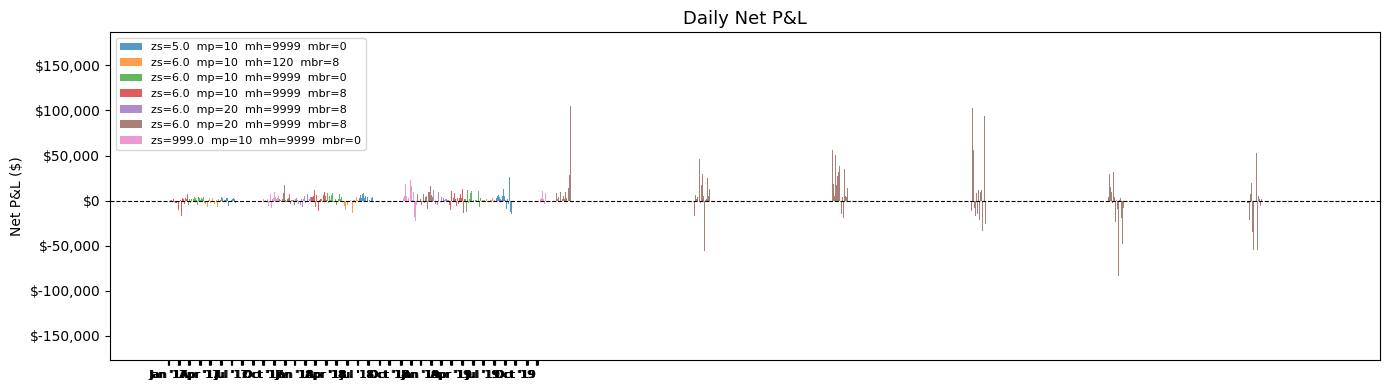

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# When multiple runs share the same dates, offset bars slightly so they don't overlap
n = len(runs)
width = 0.8 / max(n, 1)

for i, (lbl, r) in enumerate(zip(labels, runs)):
    pnl = r["pnl"]
    color = colors[i % len(colors)]
    offset = (i - (n - 1) / 2) * width

    pos_mask = pnl["net_pnl"] >= 0
    ax.bar(
        np.arange(len(pnl)) + offset,
        pnl["net_pnl"].where(pos_mask, 0),
        width=width, color=color, alpha=0.75, label=lbl,
    )
    ax.bar(
        np.arange(len(pnl)) + offset,
        pnl["net_pnl"].where(~pos_mask, 0),
        width=width, color=color, alpha=0.75,
    )

# x-axis: show monthly labels
dates = runs[0]["pnl"].index
tick_positions = [i for i, d in enumerate(dates) if d.day <= 7]
tick_labels    = [dates[i].strftime("%b '%y") if dates[i].month in (1, 4, 7, 10) else "" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8, rotation=0)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Daily Net P&L", fontsize=13)
ax.set_ylabel("Net P&L ($)")
if n > 1:
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Plot 2 — Cumulative Equity Curves

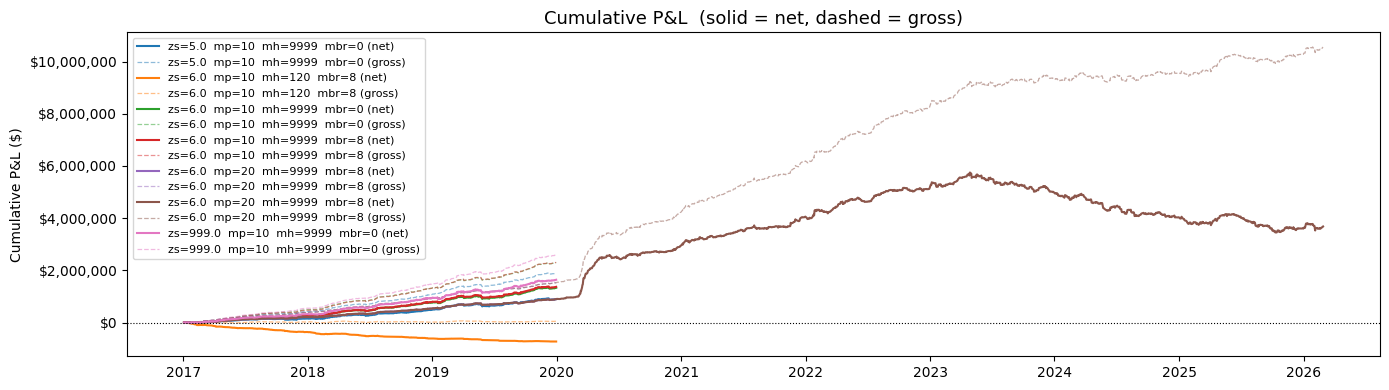

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

for i, (lbl, r) in enumerate(zip(labels, runs)):
    pnl = r["pnl"]
    color = colors[i % len(colors)]
    capital = float(pnl["portfolio_value"].iloc[0])

    cum_gross = pnl["gross_pnl"].cumsum()
    cum_net   = pnl["net_pnl"].cumsum()

    ax.plot(pnl.index, cum_net,   color=color, linewidth=1.5, label=f"{lbl} (net)")
    ax.plot(pnl.index, cum_gross, color=color, linewidth=0.9, linestyle="--", alpha=0.5,
            label=f"{lbl} (gross)")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Cumulative P&L  (solid = net, dashed = gross)", fontsize=13)
ax.set_ylabel("Cumulative P&L ($)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Plot 3 — Drawdown

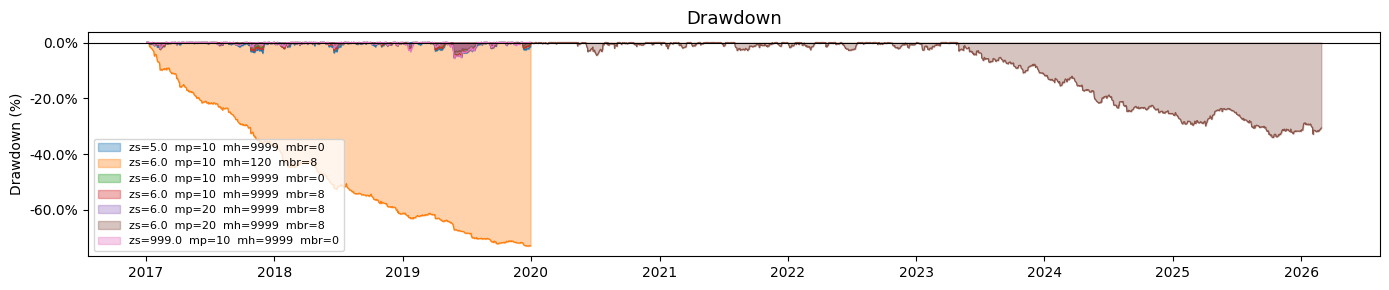

In [6]:
fig, ax = plt.subplots(figsize=(14, 3))

for i, (lbl, r) in enumerate(zip(labels, runs)):
    pnl = r["pnl"]
    color = colors[i % len(colors)]

    pv = pnl["portfolio_value"]
    peak = pv.cummax()
    dd = (pv - peak) / peak * 100  # in percent

    ax.fill_between(pnl.index, dd, 0, alpha=0.35, color=color, label=lbl)
    ax.plot(pnl.index, dd, color=color, linewidth=0.9)

ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_title("Drawdown", fontsize=13)
ax.set_ylabel("Drawdown (%)")
if n > 1:
    ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## Exit Reason Analysis

In [7]:
import math

exit_reason_rows = []
for lbl, r in zip(labels, runs):
    trades = r["trades"]
    if trades.empty or "exit_reason" not in trades.columns:
        continue
    total_trades = len(trades)
    for reason, grp in trades.groupby("exit_reason"):
        n = len(grp)
        exit_reason_rows.append({
            "Exit Reason":    reason,
            "Strategy":       lbl,
            "Count":          n,
            "% of Trades":    n / total_trades,
            "Gross P&L ($)":  grp["gross_pnl"].sum(),
            "Net P&L ($)":    grp["net_pnl"].sum(),
            "Avg Gross ($)":  grp["gross_pnl"].mean(),
            "Avg Net ($)":    grp["net_pnl"].mean(),
            "Win Rate":       (grp["net_pnl"] > 0).mean(),
        })

exit_df = pd.DataFrame(exit_reason_rows).set_index(["Exit Reason", "Strategy"]).sort_index()

fmt = {
    "% of Trades":   lambda x: f"{x:.1%}",
    "Gross P&L ($)": lambda x: f"{x:,.0f}",
    "Net P&L ($)":   lambda x: f"{x:,.0f}",
    "Avg Gross ($)": lambda x: f"{x:,.1f}",
    "Avg Net ($)":   lambda x: f"{x:,.1f}",
    "Win Rate":      lambda x: f"{x:.1%}",
}
exit_df.style.format(fmt)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

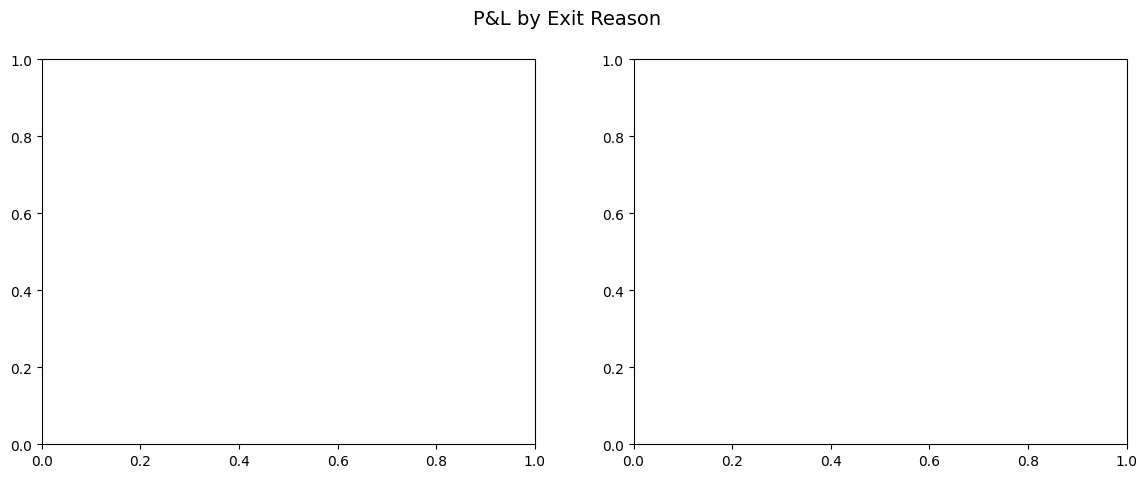

In [8]:
reasons = sorted(exit_df.index.get_level_values("Exit Reason").unique())
n_runs = len(runs)
n_reasons = len(reasons)

x = np.arange(n_reasons)
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("P&L by Exit Reason", fontsize=14)

for ax, pnl_col, title in [
    (axes[0], "Gross P&L ($)", "Gross P&L by Exit Reason"),
    (axes[1], "Net P&L ($)",   "Net P&L by Exit Reason"),
]:
    for i, (lbl, r) in enumerate(zip(labels, runs)):
        vals = []
        for reason in reasons:
            try:
                vals.append(exit_df.loc[(reason, lbl), pnl_col])
            except KeyError:
                vals.append(0.0)
        offset = (i - (n_runs - 1) / 2) * bar_width
        color = colors[i % len(colors)]
        ax.bar(x + offset, vals, width=bar_width, color=color, alpha=0.8, label=lbl)

    ax.set_xticks(x)
    ax.set_xticklabels(reasons, fontsize=10)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("P&L ($)")
    if n_runs > 1:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()